In [32]:
import sys

import numpy as np
import pandas as pd
import arviz as az

from math import sqrt

from collections import defaultdict

from scipy.stats import truncnorm, norm, truncexpon
from scipy.linalg import inv, cholesky
from scipy.optimize import linprog
import scipy.interpolate as si

from sklearn.metrics import accuracy_score
from sklearn.svm import LinearSVC

from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

import os
import pickle
import pyreadr

import networkx as nx

from joblib import Parallel, delayed 
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns


# Fitted value curve

In [59]:
# ----------------------------------------
# Helper functions
# ----------------------------------------
def ilp_map_batch(c_matrix):
    """
    Vectorized version of ilp_map for d = 2.

    Parameters:
    - c_matrix: (n_samples, 2) array of simulated latent variables

    Returns:
    - y_matrix: (n_samples, 2) array of binary outputs
    """
    y = np.zeros_like(c_matrix, dtype=int)

    # First condition: c[0] > max(c[1], 0)
    cond1 = c_matrix[:, 0] > np.maximum(c_matrix[:, 1], 0)
    y[cond1, 0] = 1

    # Second condition: c[1] > max(c[0], 0)
    cond2 = c_matrix[:, 1] > np.maximum(c_matrix[:, 0], 0)
    y[cond2, 1] = 1

    return y



def compute_ilp_probs(mu, n_sim=10000):
    """
    Simulates from N(mu, I_d) and estimates probabilities for each binary outcome
    using the vectorized ILP mapping.
    """
    zeta_sim = np.random.randn(n_sim, len(mu)) + mu  # shape: (n_sim, d)
    y_sim = ilp_map_batch(zeta_sim)
    return {
        "(1,0)": np.mean(np.all(y_sim == [1, 0], axis=1)),
        "(0,1)": np.mean(np.all(y_sim == [0, 1], axis=1)),
        "(1,1)": np.mean(np.all(y_sim == [1, 1], axis=1)),
        "(0,0)": np.mean(np.all(y_sim == [0, 0], axis=1)),
    }



from scipy.interpolate import UnivariateSpline

def smooth_df_probs(df, smoothness=1):
    """
    Smooth each probability column as a function of x using splines,
    and renormalize so each row sums to ~1.
    """
    df_smoothed = df.copy()
    x = df['x'].values

    # Apply smoothing to each class column
    for col in df.columns[1:]:
        y = df[col].values
        spline = UnivariateSpline(x, y, s=smoothness)
        df_smoothed[col] = spline(x)

    # Optional: renormalize each row to ensure sum ~ 1
    prob_matrix = df_smoothed.iloc[:, 1:].values
    row_sums = prob_matrix.sum(axis=1, keepdims=True)
    prob_matrix = prob_matrix / row_sums

    df_smoothed.iloc[:, 1:] = prob_matrix
    return df_smoothed




In [61]:
read_dir = os.path.join("../../results", "runs", "probit", "probit_default")

# -------------------------------
# Load Data
# -------------------------------

def read_rds_array(path):
    return np.array(pyreadr.read_r(path)[None])

beta_true = read_rds_array(os.path.join(read_dir, "beta_true.rds"))        # (p, d)
beta_samples_probit = read_rds_array(os.path.join(read_dir, "beta_samples_unconstrained.rds"))  # (iter, p, d)
beta_samples_augmented = read_rds_array(os.path.join(read_dir, "beta_samples_constrained.rds"))  # (iter, p, d)

X = read_rds_array(os.path.join(read_dir, "X.rds"))                        # (n, p)
y = read_rds_array(os.path.join(read_dir, "y.rds"))                        # (n, d)


# -------------------------------
# Posterior Mean
# -------------------------------

thin_start = 5000
thin_step = 10
beta_post_mean_probit = np.mean(beta_samples_probit[thin_start::thin_step], axis=0)
beta_post_mean_augmented = np.mean(beta_samples_augmented[thin_start::thin_step], axis=0)

n, p = X.shape
d = y.shape[1]

# -------------------------------
# Predicted Probabilities: Probit
# -------------------------------

mu_probit = X @ beta_post_mean_probit
prob = norm.cdf(mu_probit)

df_pred = pd.DataFrame({
    "x": X[:, 1],
    "(0,0)": (1 - prob[:, 0]) * (1 - prob[:, 1]),
    "(1,0)": prob[:, 0] * (1 - prob[:, 1]),
    "(0,1)": (1 - prob[:, 0]) * prob[:, 1],
    "(1,1)": prob[:, 0] * prob[:, 1],
})

# -------------------------------
# Predicted Probabilities: Augmented (ILP)
# -------------------------------

mu_aug = X @ beta_post_mean_augmented
prob_dict_aug = {k: [] for k in ["(0,0)", "(1,0)", "(0,1)", "(1,1)"]}

for i in range(n):
    if i % 50 == 0:
        print(f"[Augmented] Simulating for row {i}")
    probs = compute_ilp_probs(mu_aug[i], n_sim=10000)
    for key in prob_dict_aug:
        prob_dict_aug[key].append(probs[key])

df_pred_aug = pd.DataFrame({
    "x": X[:, 1],
    **prob_dict_aug
})

# -------------------------------
# Predicted Probabilities: Ground Truth
# -------------------------------

mu_true = X @ beta_true
prob_dict_true = {k: [] for k in ["(0,0)", "(1,0)", "(0,1)", "(1,1)"]}

for i in range(n):
    if i % 50 == 0:
        print(f"[Ground Truth] Simulating for row {i}")
    probs = compute_ilp_probs(mu_true[i], n_sim=10000)
    for key in prob_dict_true:
        prob_dict_true[key].append(probs[key])

df_pred_true = pd.DataFrame({
    "x": X[:, 1],
    **prob_dict_true
})





[Augmented] Simulating for row 0
[Augmented] Simulating for row 50
[Augmented] Simulating for row 100
[Augmented] Simulating for row 150
[Augmented] Simulating for row 200
[Augmented] Simulating for row 250
[Augmented] Simulating for row 300
[Augmented] Simulating for row 350
[Augmented] Simulating for row 400
[Augmented] Simulating for row 450
[Augmented] Simulating for row 500
[Augmented] Simulating for row 550
[Augmented] Simulating for row 600
[Augmented] Simulating for row 650
[Augmented] Simulating for row 700
[Augmented] Simulating for row 750
[Augmented] Simulating for row 800
[Augmented] Simulating for row 850
[Augmented] Simulating for row 900
[Augmented] Simulating for row 950
[Ground Truth] Simulating for row 0
[Ground Truth] Simulating for row 50
[Ground Truth] Simulating for row 100
[Ground Truth] Simulating for row 150
[Ground Truth] Simulating for row 200
[Ground Truth] Simulating for row 250
[Ground Truth] Simulating for row 300
[Ground Truth] Simulating for row 350
[G

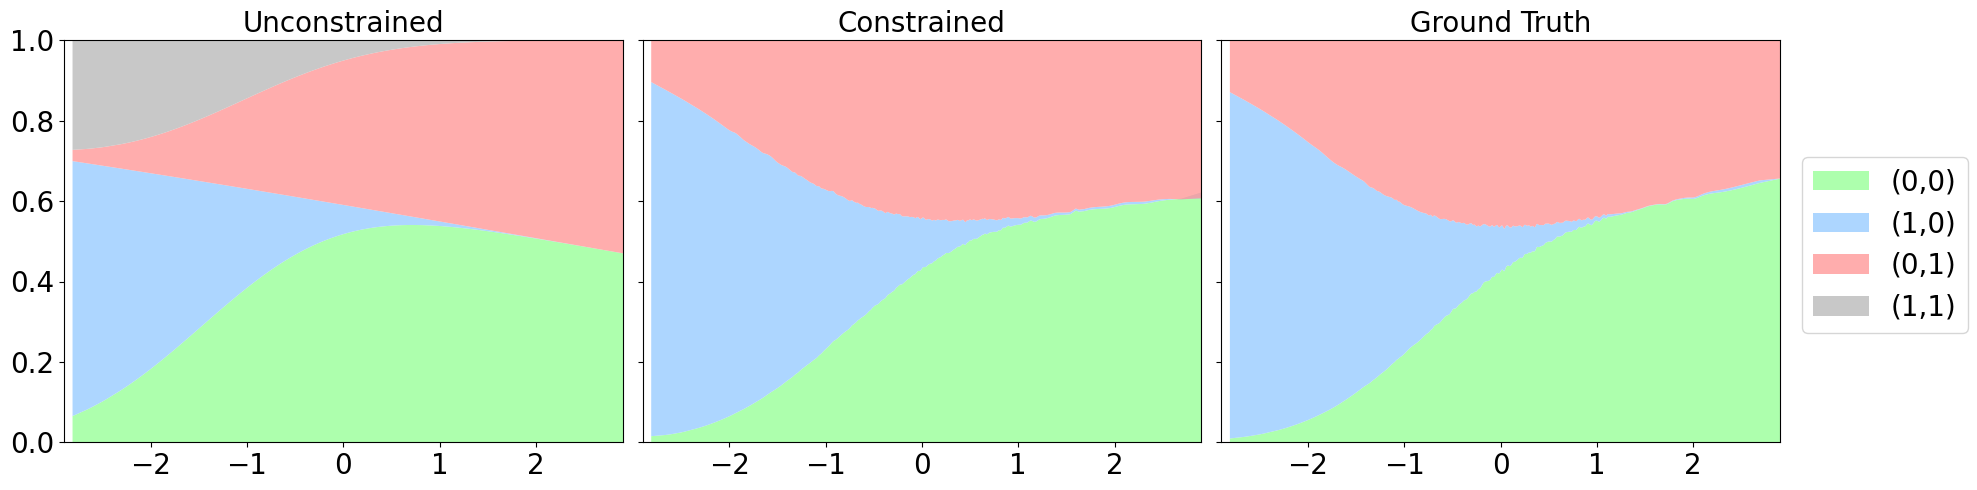

In [62]:
# Get the smooth version for better visualization
df_pred_aug_s = smooth_df_probs(df_pred_aug, smoothness=0.02)
df_pred_true_s = smooth_df_probs(df_pred_true, smoothness=0.02)


# Melt wide dataframes to long format
df_pred_long = df_pred.melt(id_vars="x", var_name="Y", value_name="prob")
df_pred_aug_long = df_pred_aug_s.melt(id_vars="x", var_name="Y", value_name="prob")
df_pred_true_long = df_pred_true_s.melt(id_vars="x", var_name="Y", value_name="prob")

# Add Method labels
df_pred_long["Method"] = "Unconstrained"
df_pred_aug_long["Method"] = "Constrained"
df_pred_true_long["Method"] = "Ground Truth"

# Combine into one long-form dataframe
df_all = pd.concat([df_pred_long, df_pred_aug_long, df_pred_true_long], ignore_index=True)

# Function to pivot and prepare data for stacking
def prepare_stacked(df_method):
    df_sorted = df_method.sort_values("x")
    df_pivot = df_sorted.pivot(index="x", columns="Y", values="prob").fillna(0)
    # Ensure column order
    df_pivot = df_pivot[["(0,0)", "(1,0)", "(0,1)", "(1,1)"]]
    return df_pivot

# Setup plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
methods = ["Unconstrained", "Constrained", "Ground Truth"]
long_dfs = [df_pred_long, df_pred_aug_long, df_pred_true_long]
colors = ["#99ff99", "#99ccff", "#ff9999", "#bbbbbb"]

for ax, method, df_method in zip(axes, methods, long_dfs):
    df_method = df_method[df_method["Method"] == method]
    df_stacked = prepare_stacked(df_method)
    x_vals = df_stacked.index.values
    y_vals = df_stacked.values.T  # shape: (4, n_points)
    
    ax.stackplot(x_vals, y_vals, labels=df_stacked.columns, colors=colors, alpha=0.8)
    ax.set_title(method, fontsize=20)
    # ax.set_xlabel("X[:, 1]")
    ax.set_xlim([-2.9, 2.9])
    ax.set_ylim([0, 1])
    ax.tick_params(axis='x', labelsize=20)
    ax.tick_params(axis='y', labelsize=20)
    ax.grid(False)

# axes[0].set_ylabel("Predicted Probability")

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center", ncol=1, bbox_to_anchor=(1.05, 0.5), fontsize=20)

plt.tight_layout()
plt.show()


# Signal recovery and computational efficiency under various dimensions

# Data analysis on waterfowl matching